# 2.1.1: Article Classification — Word2Vec + Random Forest

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from gensim.models import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

## Load Data

In [3]:
df = pd.read_csv('data/articles_handout.csv')
print(f'Shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts().sort_index()}')
df.head()

Shape: (727, 2)
Label distribution:
label
0    210
1    242
2    275
Name: count, dtype: int64


,text,label
0,boothroyd calls for lords speaker betty boothr...,1
1,stuart joins norwich from addicks norwich have...,2
2,tories urge change at the top tory delegates...,1
3,celtic unhappy over bulgaria date martin o nei...,2
4,green fear for transport ballot the green part...,1


## Text Preprocessing

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t not in string.punctuation]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

df['tokens'] = df['text'].apply(preprocess_text)
print(f'Example tokens: {df["tokens"].iloc[0][:10]}')

Example tokens: ['boothroyd', 'call', 'lord', 'speaker', 'betty', 'boothroyd', 'said', 'house', 'lord', 'need']


## Word2Vec

In [5]:
w2v_model = Word2Vec(sentences=df['tokens'], sg=0, vector_size=100, window=5, min_count=1, workers=4, seed=42)
print(f'Vocabulary size: {len(w2v_model.wv)}')

def doc_vector(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X = np.array([doc_vector(tokens, w2v_model) for tokens in df['tokens']])
y = df['label'].values
print(f'Feature matrix: {X.shape}')

Vocabulary size: 16747
Feature matrix: (727, 100)


## Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 581, Test: 146


## Model: Random Forest + GridSearchCV

In [7]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV accuracy: 0.8830


## Evaluation

In [8]:
y_pred = grid_search.predict(X_test)

print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8699

              precision    recall  f1-score   support

           0       0.84      0.76      0.80        42
           1       0.90      0.94      0.92        49
           2       0.86      0.89      0.88        55

    accuracy                           0.87       146
   macro avg       0.87      0.86      0.87       146
weighted avg       0.87      0.87      0.87       146



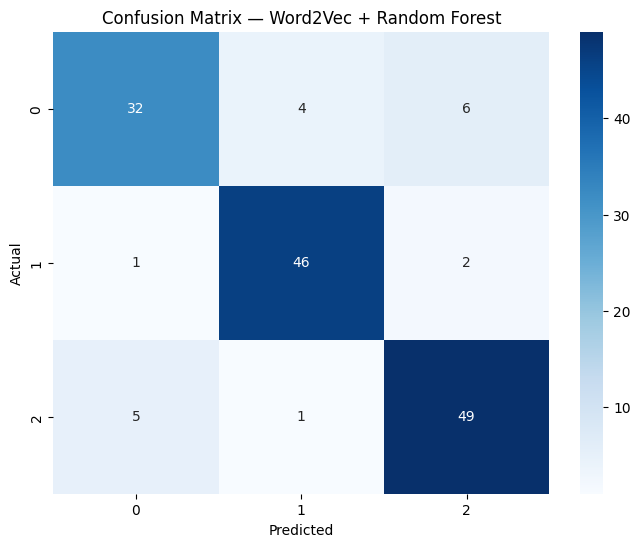

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Word2Vec + Random Forest')
plt.show()